In [2]:
# Load the customer dataset
import pandas as pd


df = pd.read_csv('Mall_Customers.csv')

# Displaying first 5 records

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Display information about dataset

# Shows:
# Total rows and columns
# Data types of each column
# Missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Check whether dataset contains any missing values

df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [5]:
# seeing summary of columns

# Shows: Mean,Minimum value,Maximum value,Standard deviation

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


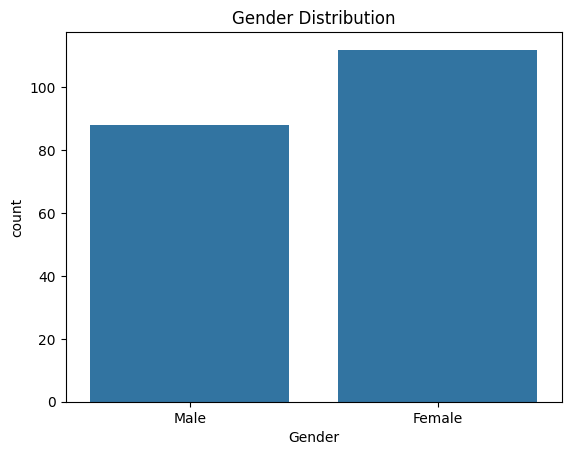

In [7]:
# See the Distribution of gender:

#check number of male and female customers

import matplotlib.pyplot as plt
import seaborn as sns



sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

plt.show()

# Female customers are slightly higher than male customers.
# The dataset is fairly balanced and contains both genders.

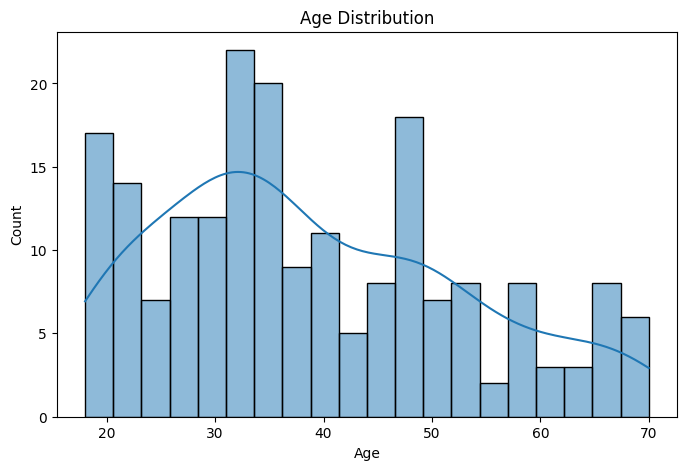

In [8]:
#Age Distribution:

# Visualize customer age distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')

plt.show()

# Most customers are between 25 and 40 years old.
# Very young and very old customers are fewer in number.
# The majority of customers belong to the adult age group.

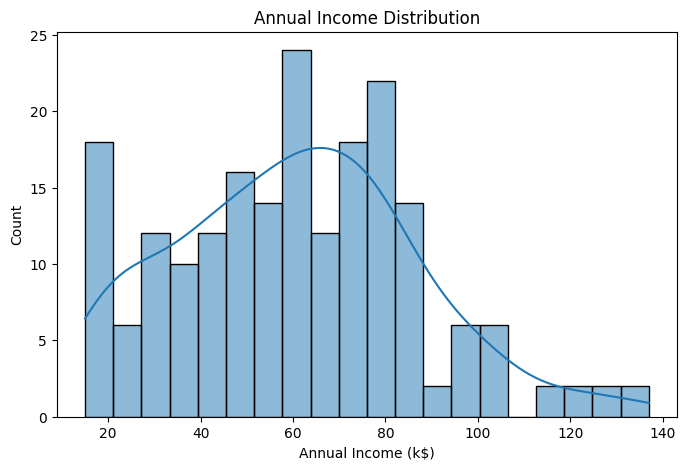

In [9]:
#Annual Income Distribution:


# Visualize annual income distribution of customers

plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')

plt.show()

# Most customers have annual income between 40k and 80k.
# Very high income customers are limited.
# Income values are spread across different ranges.

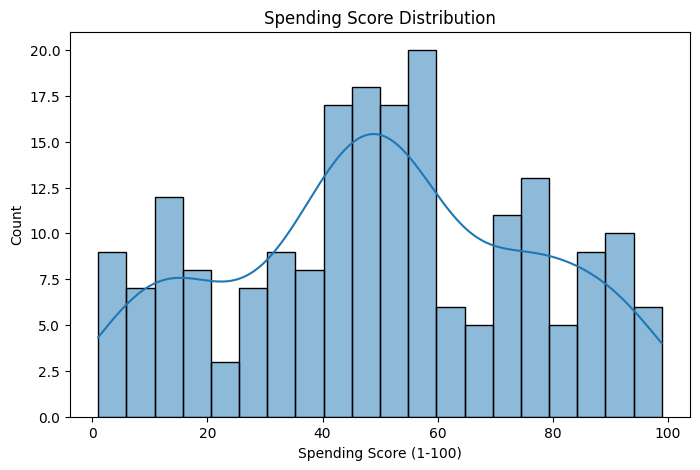

In [10]:
#spending behavior of customers

# Spending Score ranges from 1 to 100

plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')

plt.show()

# Spending scores are distributed across low, medium and high ranges.
# Many customers have spending scores around 40 to 60.
# Customer buying behavior varies significantly.

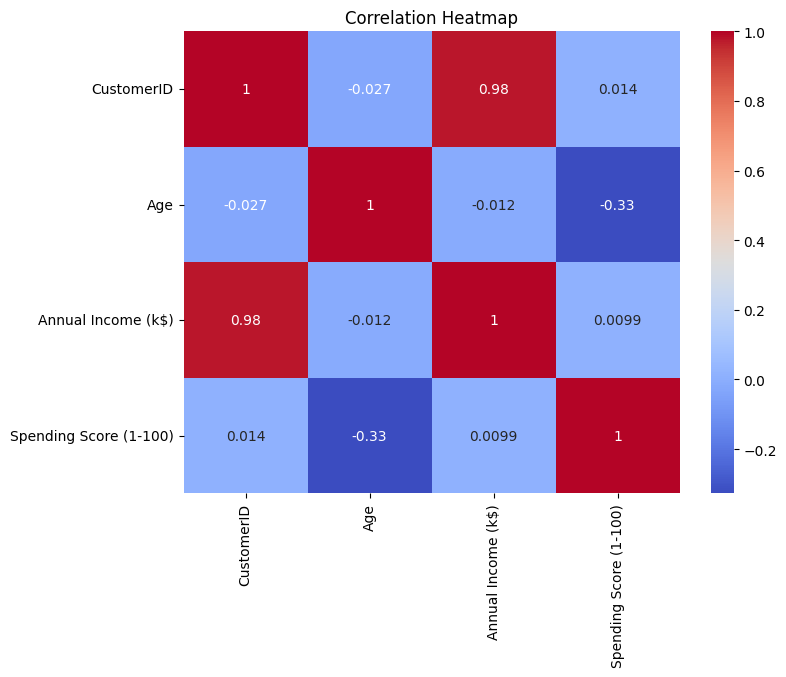

In [12]:
# Select only numerical columns
import numpy as np

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


# Age has a slight negative relationship with Spending Score.
# Older customers generally spend less than younger customers.
# Annual Income has very little correlation with Spending Score.
# CustomerID should not affect clustering because it is only an identifier.

In [13]:
# Select important features for customer segmentation

# Age
# Annual Income
# Spending Score

X = df[['Age',
        'Annual Income (k$)',
        'Spending Score (1-100)']]

print("Selected Features Shape:")
print(X.shape)

Selected Features Shape:
(200, 3)


In [15]:
# features Scaling:
# K-Means works better when features are on similar scale

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Dataset Shape:")
print(X_scaled.shape)

Scaled Dataset Shape:
(200, 3)


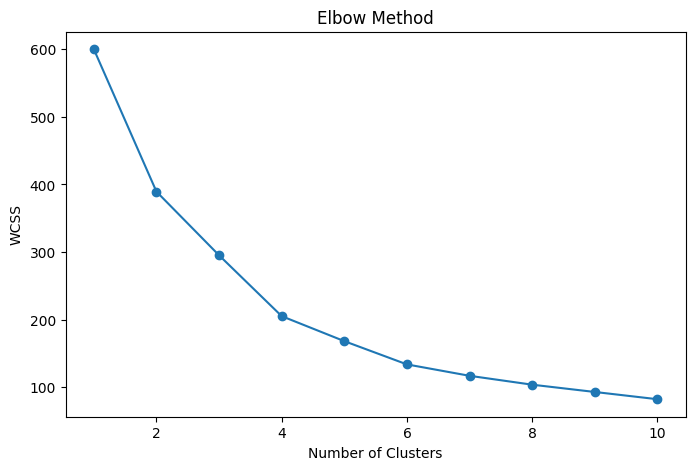

In [17]:
#Using Elbow Method:

# Find optimal number of clusters

# WCSS = Within Cluster Sum of Squares

from sklearn.cluster import KMeans
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.show()


# WCSS decreases as the number of clusters increases.
# The rate of decrease becomes slower after K = 5.
# This creates an elbow point at K = 5.

In [18]:
#K-Means:

# Train K-Means clustering model

# K=5 selected from Elbow Method

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Assign cluster labels

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels into dataset

df['Cluster'] = clusters

print("Cluster Labels Added Successfully")

df.head()

Cluster Labels Added Successfully


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [20]:
#PCA:

# Reduce dataset dimensions from 3 features to 2 features

# PCA helps visualize clusters in 2D space

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

# Create PCA dataframe

pca_df = pd.DataFrame(
    pca_features,
    columns=['PC1','PC2']
)

# Add cluster labels

pca_df['Cluster'] = clusters

pca_df.head()


# Five customer groups can be observed in the PCA plot.
# Most clusters are separated from each other with limited overlap.
# Clear separation indicates that K-Means successfully identified different customer segments.
# Customers within the same cluster have similar spending behavior.

,PC1,PC2,Cluster
0,-0.615720,-1.763481,1
1,-1.665793,-1.820747,1
2,0.337862,-1.674799,0
3,-1.456573,-1.772430,1
4,-0.038465,-1.662740,1


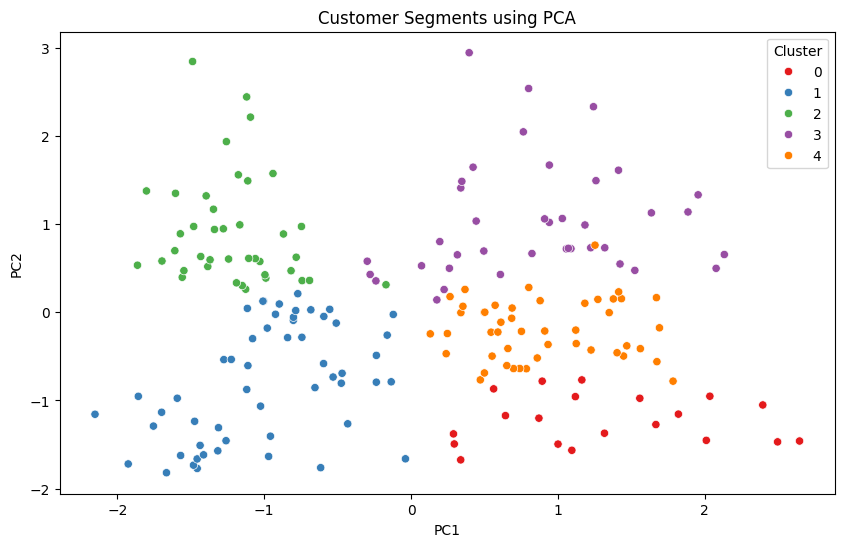

In [21]:
# Visualize customer clusters after PCA

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title('Customer Segments using PCA')

plt.show()



In [23]:
# Calculate average values of each cluster

# Helps understand customer behavior in each segment

cluster_summary = df.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

print(cluster_summary)


# Cluster 2 has the highest income and highest spending score.
# Cluster 3 has high income but low spending score.
# Cluster 0 has low income and low spending score.
# Cluster 1 consists of younger customers with relatively higher spending behavior.
# Cluster 4 contains older customers with average spending patterns.


               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        46.250000           26.750000               18.350000
1        25.185185           41.092593               62.240741
2        32.875000           86.100000               81.525000
3        39.871795           86.102564               19.358974
4        55.638298           54.382979               48.851064


In [24]:
#Business view:

# Different customer groups require different marketing approaches.
# High-value customers can be targeted with premium offers and loyalty programs.
# High-income but low-spending customers can be encouraged through personalized promotions.
# Budget-conscious customers can be targeted with discounts and bundle offers.
# Customer segmentation helps improve marketing effectiveness and customer engagement.

In [ ]:
# Final Remarks:

#in Elbow Method graph observed that WCSS decreased significantly from K=1 to K=5. After K=5, the reduction in WCSS became much smaller,
#meaning additional clusters were not providing substantial improvement. Therefore, K=5 was selected as the optimal number of customer segments.

In [26]:
# Create outputs folder

import os

os.makedirs('outputs', exist_ok=True)

print("Outputs folder created successfully")

Outputs folder created successfully


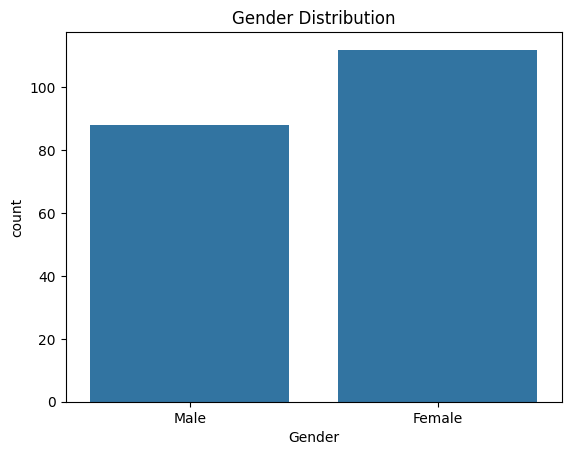

In [27]:
# Gender Distribution

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution')

# Save graph

plt.savefig(
    'outputs/gender_distribution.png',
    bbox_inches='tight'
)

plt.show()

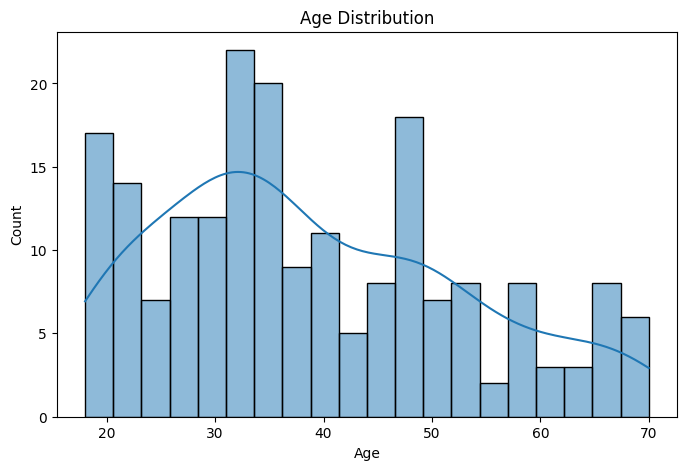

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title('Age Distribution')

plt.savefig(
    'outputs/age_distribution.png',
    bbox_inches='tight'
)

plt.show()

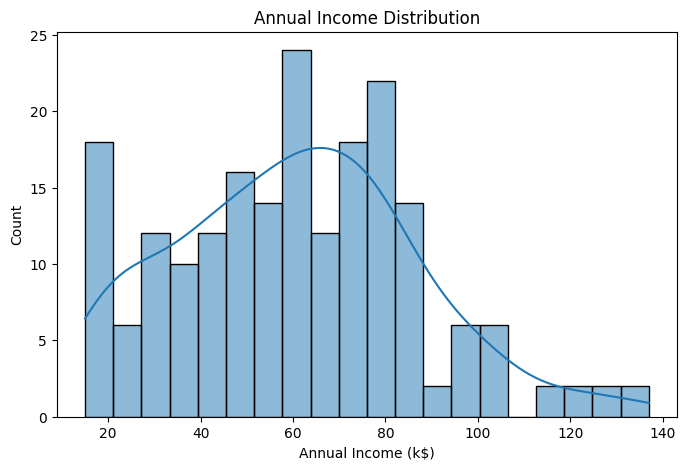

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')

plt.savefig(
    'outputs/income_distribution.png',
    bbox_inches='tight'
)

plt.show()

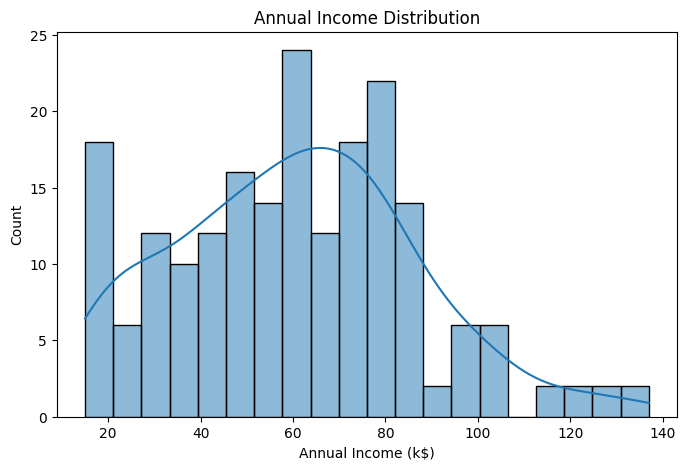

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title('Annual Income Distribution')

plt.savefig(
    'outputs/income_distribution.png',
    bbox_inches='tight'
)

plt.show()

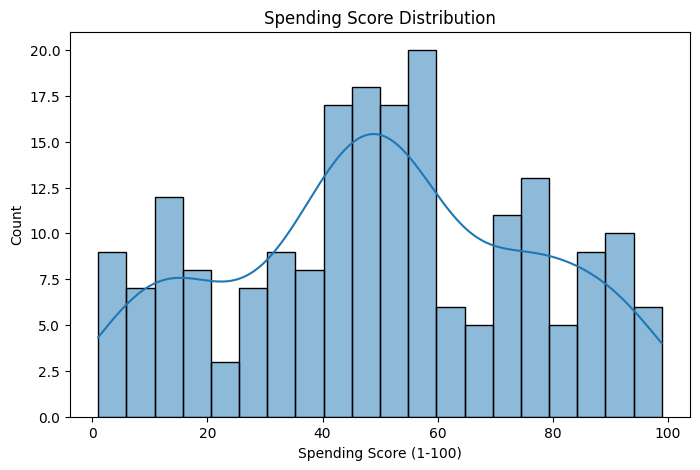

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title('Spending Score Distribution')

plt.savefig(
    'outputs/spending_distribution.png',
    bbox_inches='tight'
)

plt.show()

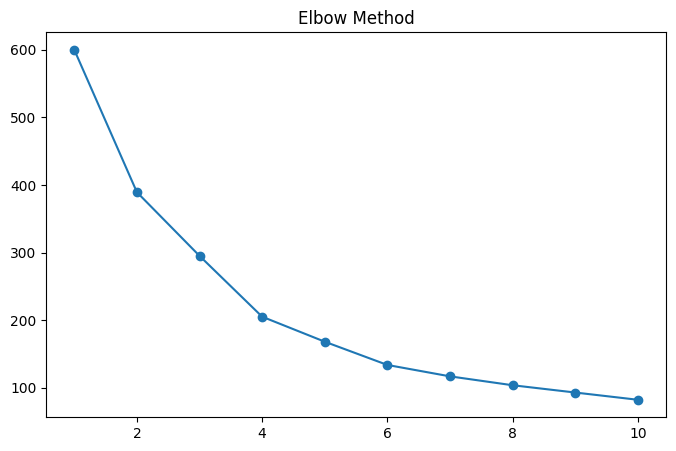

In [32]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')

plt.savefig(
    'outputs/elbow_method.png',
    bbox_inches='tight'
)

plt.show()

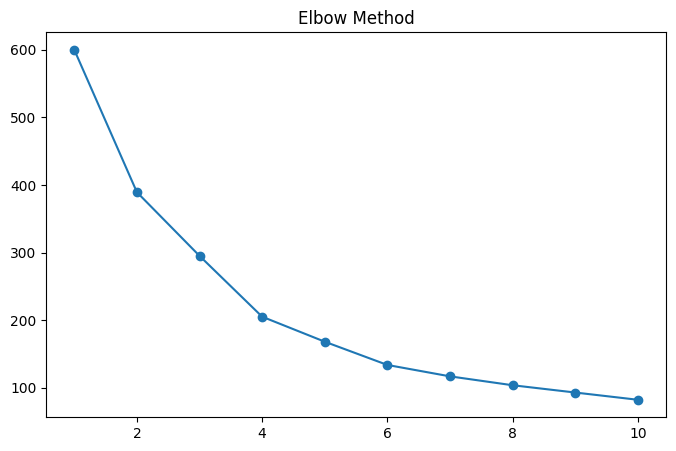

In [33]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')

plt.savefig(
    'outputs/elbow_method.png',
    bbox_inches='tight'
)

plt.show()

In [34]:
!zip -r outputs.zip outputs

  adding: outputs/ (stored 0%)
  adding: outputs/income_distribution.png (deflated 8%)
  adding: outputs/elbow_method.png (deflated 9%)
  adding: outputs/spending_distribution.png (deflated 9%)
  adding: outputs/gender_distribution.png (deflated 21%)
  adding: outputs/age_distribution.png (deflated 9%)


In [35]:
from google.colab import files

files.download('outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>